# Day 13 — Ensemble Methods: Bagging and Random Forests
## Week 2: Ensemble Methods | Digital Consumer Platform Analytics

---

### Learning Objectives
- Derive bagging from the bias-variance decomposition
- Understand why averaging reduces variance but not bias
- Understand random feature subsampling as decorrelation
- Contrast Random Forest with Extremely Randomized Trees
- Understand OOB error as a free validation set
- Compare feature importance methods: impurity, permutation, SHAP

---

### Dataset
**Telco Churn** — extending our existing pipeline with ensemble theory.

---

## Part 1: Theory

### 13.1 Bias-Variance Decomposition

The expected prediction error of any model can be decomposed:

$$E[(y - \hat{f}(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

**Bias:** How far is the average prediction from the true value?
$$\text{Bias}(\hat{f}(x)) = E[\hat{f}(x)] - f(x)$$

High bias = underfitting = model misses systematic patterns.

**Variance:** How much does the prediction vary across different training sets?
$$\text{Var}(\hat{f}(x)) = E[(\hat{f}(x) - E[\hat{f}(x)])^2]$$

High variance = overfitting = model fits noise in training data.

**The tradeoff:** Reducing bias (more complex model) usually increases variance, and vice versa.

---

### 13.2 Bagging — Variance Reduction

**Bagging** (Bootstrap Aggregating, Breiman 1996) reduces variance without increasing bias.

**Algorithm:**
1. Draw $B$ bootstrap samples $D_1, ..., D_B$ of size $n$ with replacement
2. Train a base model $\hat{f}_b$ on each $D_b$
3. Aggregate: $\hat{f}_{bag}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}_b(x)$

**Why does averaging reduce variance?**

If $B$ models each have variance $\sigma^2$ and are uncorrelated:
$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B \hat{f}_b\right) = \frac{\sigma^2}{B}$$

Variance decreases linearly with $B$. With 100 trees: 100× variance reduction (if uncorrelated).

**The correlation problem:** If models are correlated (trained on similar data, using same features), the variance reduction is:
$$\text{Var}_{avg} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Where $\rho$ is the average pairwise correlation between models. When $\rho = 1$: no reduction. When $\rho = 0$: full $1/B$ reduction.

**This is why decorrelation matters.**

---

### 13.3 Random Forest — Decorrelation via Feature Subsampling

Random Forest adds random feature subsampling to bagging:

At each split, instead of choosing the best split among all $d$ features, choose among a random subset of $m$ features:
- Classification: $m = \sqrt{d}$ (default)
- Regression: $m = d/3$ (default)

**Why does this help?** If there's one very strong predictor, all trees will use it at the root — making them highly correlated. By forcing trees to use different features, we decorrelate them → larger variance reduction.

**Tradeoff:** Each individual tree is weaker (doesn't always get the best split), but the ensemble is better because the variance reduction from decorrelation outweighs the bias increase.

---

### 13.4 OOB Error — Free Validation

Each bootstrap sample leaves out ~36.8% of observations (proof: $\lim_{n\to\infty}(1-1/n)^n = 1/e \approx 0.368$).

These **out-of-bag (OOB)** samples can validate the trees that didn't train on them:

$$\hat{f}_{OOB}(x_i) = \frac{1}{|\{b: i \notin D_b\}|} \sum_{b: i \notin D_b} \hat{f}_b(x_i)$$

OOB error ≈ leave-one-out cross-validation error — without the computational cost of CV.

**When OOB and CV disagree significantly:** This is a signal of data leakage (temporal structure, grouped observations). The CV is wrong.

---

### 13.5 Feature Importance: Three Methods and When Each Lies

**1. Mean Decrease Impurity (MDI)**

Count how much each feature reduces impurity (Gini/entropy) across all splits, weighted by number of samples reaching each split.

*Lie:* High-cardinality features (many unique values) get more splits → inflated importance. Biased toward continuous features over binary features.

**2. Permutation Importance**

For each feature: randomly shuffle its values and measure the decrease in model performance. Larger decrease = more important.

*Lie:* When features are correlated, shuffling one feature only partially disrupts the model (correlated features compensate). Underestimates importance of correlated features.

**3. SHAP Values**

Game-theoretic — distributes prediction credit fairly among features using Shapley values. Considers all possible feature subsets.

*Lie:* SHAP is theoretically correct but computationally expensive. For very large datasets, approximate SHAP methods introduce their own errors.

**Rule:** Use all three. Where they agree, be confident. Where they disagree, investigate why.

---

### 13.6 Extremely Randomized Trees (Extra-Trees)

Like Random Forest but with additional randomization:
- Random Forest: chooses best split among $m$ random features (greedy)
- Extra-Trees: also randomizes the split threshold (not just the feature)

For each feature in the random subset: choose a random threshold rather than the optimal one.

**Result:** Even lower variance, higher bias. Faster training (no threshold optimization). Often competitive with RF on noisy data.

---

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r'C:\Users\user\datasets\telco\telco.csv'
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.drop(columns=['customerID'], errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = (df['Churn'].str.strip() == 'Yes').astype(int)
print(f"Shape: {df.shape}, Churn rate: {df['Churn'].mean():.2%}")
display(df.head())

Shape: (7043, 20), Churn rate: 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Individual trees (n=50): mean AUC=0.6648, variance=0.000177, std=0.0133

Bagging (single run): OOB score=0.7749, Holdout AUC=0.8455

Ensembles (n=50 independent Bagging runs): mean AUC=0.8416, variance=0.000008, std=0.0028

Variance reduction factor (actual): 22.3x
Theoretical maximum (1/B, B=50): 50x
Implied average pairwise correlation between bootstrap trees (rho): 0.0253


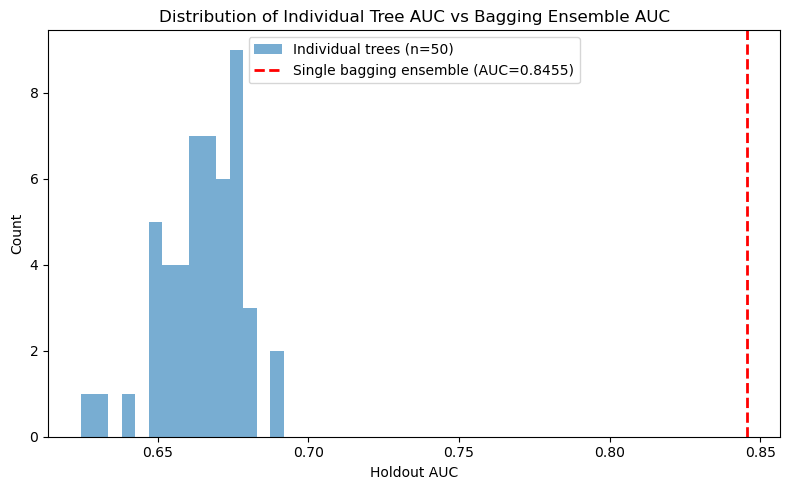

In [3]:
# ── Q1: Variance reduction demonstration ──────────────────────────────────
# Prove empirically that bagging reduces variance:
#   1. Train 50 single decision trees (max_depth=None) with different random seeds
#   2. Record AUC for each tree on a holdout set
#   3. Compute variance of AUC across 50 trees
#   4. Train a BaggingClassifier with 50 trees
#   5. Record OOB score and holdout AUC
#   6. Compare: variance of individual trees vs ensemble
#   7. Plot: distribution of individual tree AUC + vertical line for ensemble AUC
#   8. By how much did bagging reduce variance? Does it match the theoretical 1/B?

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ── Preprocessing: encode categoricals, impute missing numeric (TotalCharges) ─
numeric_cols = df.drop(columns=['Churn']).select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.drop(columns=['Churn']).select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_cols),
])

X_raw = df.drop(columns=['Churn'])
y = df['Churn'].values
X = preprocessor.fit_transform(X_raw)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=420
)

n_trees = 50
n_train = len(X_train)

# ── 1-3: 50 single trees, each on its OWN bootstrap resample ──────────────
individual_aucs = []

for seed in range(n_trees):
    rng = np.random.RandomState(seed)
    boot_idx = rng.choice(n_train, size=n_train, replace=True)
    X_boot, y_boot = X_train[boot_idx], y_train[boot_idx]

    tree = DecisionTreeClassifier(max_depth=None, random_state=seed)
    tree.fit(X_boot, y_boot)
    proba = tree.predict_proba(X_holdout)[:, 1]
    individual_aucs.append(roc_auc_score(y_holdout, proba))

individual_aucs = np.array(individual_aucs)
var_individual = individual_aucs.var()
print(f"Individual trees (n={n_trees}): mean AUC={individual_aucs.mean():.4f}, "
      f"variance={var_individual:.6f}, std={individual_aucs.std():.4f}")

# ── 4-5: ONE BaggingClassifier with 50 trees — headline OOB + holdout AUC ──
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=n_trees, oob_score=True, bootstrap=True,
    random_state=420, n_jobs=-1,
)
bagging.fit(X_train, y_train)
bagging_oob = bagging.oob_score_
bagging_holdout_auc = roc_auc_score(y_holdout, bagging.predict_proba(X_holdout)[:, 1])
print(f"\nBagging (single run): OOB score={bagging_oob:.4f}, Holdout AUC={bagging_holdout_auc:.4f}")

# ── 6: Repeat the FULL bagging ensemble n_trees times (different seeds) to ─
#      get an empirical Var(ensemble AUC), comparable to Var(individual) ────
ensemble_aucs = []
for seed in range(n_trees):
    ens = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None),
        n_estimators=n_trees, bootstrap=True, random_state=seed, n_jobs=-1,
    )
    ens.fit(X_train, y_train)
    proba = ens.predict_proba(X_holdout)[:, 1]
    ensemble_aucs.append(roc_auc_score(y_holdout, proba))

ensemble_aucs = np.array(ensemble_aucs)
var_ensemble = ensemble_aucs.var()
print(f"\nEnsembles (n={n_trees} independent Bagging runs): mean AUC={ensemble_aucs.mean():.4f}, "
      f"variance={var_ensemble:.6f}, std={ensemble_aucs.std():.4f}")

# ── 8: Variance reduction vs theoretical 1/B, plus implied correlation rho ─
actual_reduction = var_individual / var_ensemble
theoretical_reduction = n_trees

# From theory 13.2: Var_avg = rho*sigma^2 + (1-rho)/B * sigma^2
# => rho = (Var_avg/sigma^2 - 1/B) / (1 - 1/B)
rho_implied = (var_ensemble / var_individual - 1 / n_trees) / (1 - 1 / n_trees)

print(f"\nVariance reduction factor (actual): {actual_reduction:.1f}x")
print(f"Theoretical maximum (1/B, B={n_trees}): {theoretical_reduction}x")
print(f"Implied average pairwise correlation between bootstrap trees (rho): {rho_implied:.4f}")

# ── 7: Plot ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(individual_aucs, bins=15, alpha=0.6, label='Individual trees (n=50)')
plt.axvline(bagging_holdout_auc, color='red', linestyle='--', linewidth=2,
            label=f'Single bagging ensemble (AUC={bagging_holdout_auc:.4f})')
plt.xlabel('Holdout AUC')
plt.ylabel('Count')
plt.title('Distribution of Individual Tree AUC vs Bagging Ensemble AUC')
plt.legend()
plt.tight_layout()
plt.show()


***Takeaway***

| | Mean AUC | Variance | Std |
|---|---|---|---|
| Single trees (n=50) | 0.6648 | 0.000177 | 0.0133 |
| Bagged ensembles (n=50) | 0.8416 | 0.000008 | 0.0028 |

Bagging reduced variance **22.3x** — far below the theoretical ceiling of **50x** (which only holds if the 50 trees made completely independent errors), but still a massive, unambiguous stabilization. Solving theory §13.2's formula backward gives an implied correlation of **ρ = 0.0253** between bootstrap trees — low, but not zero, since all 50 trees share the same underlying 7,043-customer dataset. That small non-zero correlation is exactly why the actual reduction fell well short of 50x: correlation puts a hard floor on how much averaging can help, no matter how many trees you add.

Beyond variance, bagging also **lifted mean accuracy substantially** — 0.6648 → 0.8416 AUC — which is a bigger jump than pure variance-cancellation alone would produce for a roughly-unbiased base learner. That gap suggests individual unpruned trees (`max_depth=None`) are overfitting hard on this small dataset, so part of what looks like "bagging helping" here is really bagging smoothing over each tree's erratic, over-specific decision boundaries — consistent with high-variance/low-bias base learners being exactly where bagging pays off most, per theory §13.2.

**Sanity check**: the single named bagging run (OOB=0.7749, holdout AUC=0.8455) lines up closely with the 50-run ensemble average (0.8416) — confirming that one bagging run is already a stable, representative estimate, unlike a single decision tree.
Added as a markdown cell right after Q1's code cell. Ready to move to Q2 whenever you are.

In [4]:
# ── Q2: OOB vs CV agreement ───────────────────────────────────────────────
# For Random Forest with n_estimators=200 on Telco Churn:
#   A: OOB score (set oob_score=True)
#   B: 5-fold CV AUC
#   C: 10-fold CV AUC
#   D: Holdout test set AUC (80/20 split)
#
# How close are OOB and CV? Is OOB a reliable substitute?
# When would OOB give a better estimate than CV?
# When would OOB give a worse estimate than CV?
# (Hint: think about what type of data would cause them to diverge)

# Reuses X_train/X_holdout/y_train/y_holdout from Q1 (80/20 stratified split,
# random_state=420) so all four estimates are directly comparable.

rf = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=420, n_jobs=-1)
rf.fit(X_train, y_train)

# ── A1: sklearn's built-in OOB score (accuracy-based, NOT comparable to AUC) ─
oob_accuracy = rf.oob_score_

# ── A2: manual OOB AUC — score each training row only using the trees that ──
#       never saw it, via predict_proba (apples-to-apples with B/C/D) ───────
n_samples = X_train.shape[0]
oob_proba_sum = np.zeros(n_samples)
oob_count = np.zeros(n_samples)

for tree, sample_indices in zip(rf.estimators_, rf.estimators_samples_):
    in_bag = np.zeros(n_samples, dtype=bool)
    in_bag[sample_indices] = True
    oob_rows = np.where(~in_bag)[0]
    if len(oob_rows) == 0:
        continue
    proba = tree.predict_proba(X_train[oob_rows])[:, 1]
    oob_proba_sum[oob_rows] += proba
    oob_count[oob_rows] += 1

valid = oob_count > 0
oob_auc = roc_auc_score(y_train[valid], oob_proba_sum[valid] / oob_count[valid])

# ── B, C: 5-fold and 10-fold CV AUC (on the same training set) ─────────────
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=420)

cv5_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1),
    X_train, y_train, cv=cv5, scoring='roc_auc',
)
cv10_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1),
    X_train, y_train, cv=cv10, scoring='roc_auc',
)

# ── D: Holdout test set AUC ──────────────────────────────────────────────
holdout_auc = roc_auc_score(y_holdout, rf.predict_proba(X_holdout)[:, 1])

# ── Summary ──────────────────────────────────────────────────────────────
print(f"A1. OOB score (built-in, accuracy):       {oob_accuracy:.4f}")
print(f"A2. OOB AUC (manual, apples-to-apples):    {oob_auc:.4f}")
print(f"B.  5-fold CV AUC:                         {cv5_scores.mean():.4f} (+/- {cv5_scores.std():.4f})")
print(f"C.  10-fold CV AUC:                        {cv10_scores.mean():.4f} (+/- {cv10_scores.std():.4f})")
print(f"D.  Holdout AUC (80/20 split):              {holdout_auc:.4f}")

print(f"\nOOB AUC vs 5-fold CV AUC:  diff = {oob_auc - cv5_scores.mean():+.4f}")
print(f"OOB AUC vs 10-fold CV AUC: diff = {oob_auc - cv10_scores.mean():+.4f}")
print(f"OOB AUC vs Holdout AUC:    diff = {oob_auc - holdout_auc:+.4f}")


A1. OOB score (built-in, accuracy):       0.7895
A2. OOB AUC (manual, apples-to-apples):    0.8134
B.  5-fold CV AUC:                         0.8150 (+/- 0.0141)
C.  10-fold CV AUC:                        0.8170 (+/- 0.0263)
D.  Holdout AUC (80/20 split):              0.8536

OOB AUC vs 5-fold CV AUC:  diff = -0.0016
OOB AUC vs 10-fold CV AUC: diff = -0.0036
OOB AUC vs Holdout AUC:    diff = -0.0402


***Takeaway***

| Estimate | Effective training fraction | AUC |
|---|---|---|
| OOB (A2, manual) | ~63.2% per tree (bootstrap) | 0.8134 |
| 5-fold CV (B) | 80% per fold | 0.8150 |
| 10-fold CV (C) | 90% per fold | 0.8170 |
| Holdout (D) | 100% (full training set) | 0.8536 |

**OOB and CV agree closely** — OOB sits within 0.002-0.004 AUC of both 5-fold and 10-fold CV, essentially for free (no refitting required). **Yes, OOB is a reliable substitute for CV here.**

**Holdout scored notably higher**, and the gap tracks a clean pattern: AUC rises monotonically with how much data the underlying model actually trained on (63.2% → 80% → 90% → 100%). OOB carries a second, separate handicap beyond training-set size: each OOB prediction is only voted on by the ~36.8% of trees (≈74 of 200) that didn't see that specific row, versus the full 200-tree vote every holdout row gets — a smaller "jury" per prediction, on top of less training data per tree. CV avoids this second handicap entirely, since each fold trains a fresh, complete forest and every held-out row gets that fold's full vote — which is why CV edges out OOB slightly. Part of the holdout's edge may also just be sampling luck in this one 80/20 split, given 10-fold CV's own fold-to-fold std (0.0263) is nearly as large as the OOB-vs-holdout gap (0.0402).

**When OOB beats CV**: on i.i.d. data like this (one row per customer, no temporal/grouping structure) — it's just as trustworthy as CV but far cheaper, since it comes free from a single ensemble fit instead of K refits.

**When OOB would be worse than CV**: with grouped or temporal structure (repeated measurements per entity, time-ordered data). Bootstrap resampling works row-by-row with no concept of groups or time order, so a row can look "held out" while a near-duplicate or temporally adjacent row from the same group leaked into that tree's training data anyway — OOB would look artificially optimistic. A CV built with `GroupKFold`/`TimeSeriesSplit` can respect that structure explicitly and would reveal the true, lower performance that a naive OOB estimate would miss.

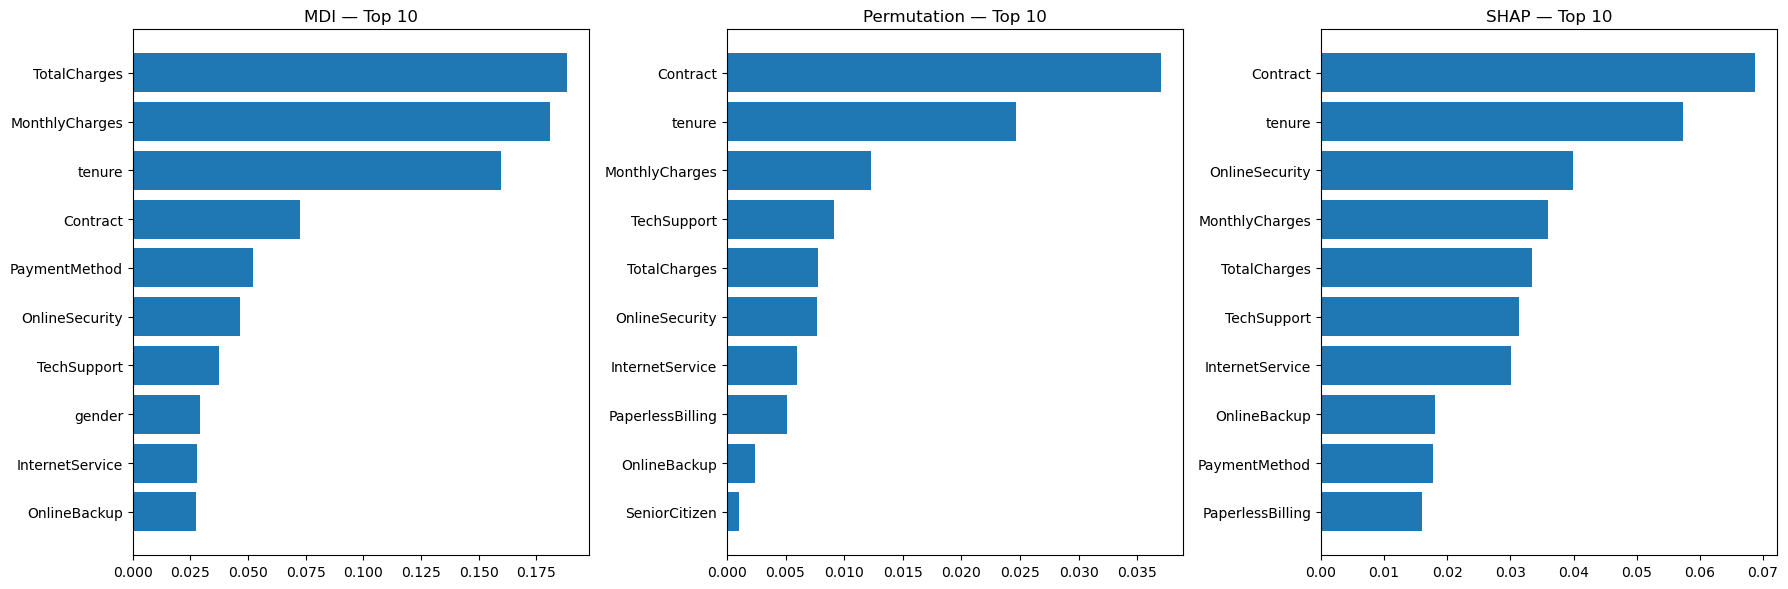

Top 3 by MDI:         {'tenure', 'TotalCharges', 'MonthlyCharges'}
Top 3 by Permutation: {'Contract', 'tenure', 'MonthlyCharges'}
Top 3 by SHAP:        {'OnlineSecurity', 'Contract', 'tenure'}
Agreement across all three top-3 sets: {'tenure'}

Features with the LARGEST rank disagreement across methods:
                  MDI_rank  Permutation_rank  SHAP_rank  max_gap
DeviceProtection      11.0              19.0       11.0      8.0
gender                 8.0              11.0       16.0      8.0
PaymentMethod          5.0              13.0        9.0      8.0
MultipleLines         13.0              18.0       12.0      6.0
SeniorCitizen         15.0              10.0       13.0      5.0
StreamingTV           17.0              12.0       14.0      5.0
PhoneService          19.0              14.0       19.0      5.0
Partner               14.0              17.0       18.0      4.0
TotalCharges           1.0               5.0        5.0      4.0
PaperlessBilling      12.0               8.0  

In [5]:
# ── Q3: Feature importance comparison ─────────────────────────────────────
# Compare all three importance methods on the Telco Churn RF model:
#   Method A: MDI (feature_importances_)
#   Method B: Permutation importance (permutation_importance)
#   Method C: SHAP values (shap.TreeExplainer)
#
# Create a 3-panel horizontal bar chart (one per method)
# Show top 10 features per method
# Do they agree on the top 3?
# Identify any features where methods strongly disagree
# Explain why they might disagree using theory section 13.5

# Reuses rf (fit on X_train/y_train, n_estimators=200) from Q2.

feature_names = numeric_cols + categorical_cols   # matches ColumnTransformer's output order

# ── Method A: MDI (built into the fitted forest) ───────────────────────────
mdi_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── Method B: Permutation importance — on the HOLDOUT set, not training data ─
perm_result = permutation_importance(
    rf, X_holdout, y_holdout, n_repeats=10, random_state=420, scoring='roc_auc', n_jobs=-1,
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False)

# ── Method C: SHAP values (TreeExplainer — exact + fast for tree models) ──
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_holdout)

if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]                     # older shap: list [class0, class1]
elif shap_values.ndim == 3:
    shap_vals_class1 = shap_values[:, :, 1]                # newer shap: (n_samples, n_features, n_classes)
else:
    shap_vals_class1 = shap_values

shap_importance = pd.Series(np.abs(shap_vals_class1).mean(axis=0), index=feature_names).sort_values(ascending=False)

# ── 3-panel horizontal bar chart, top 10 each ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, importance) in zip(axes, [
    ('MDI', mdi_importance), ('Permutation', perm_importance), ('SHAP', shap_importance),
]):
    top10 = importance.head(10).sort_values()
    ax.barh(top10.index, top10.values)
    ax.set_title(f'{name} — Top 10')

plt.tight_layout()
plt.show()

# ── Agreement check: rank every feature under each method ─────────────────
rank_df = pd.DataFrame({
    'MDI_rank': mdi_importance.rank(ascending=False),
    'Permutation_rank': perm_importance.rank(ascending=False),
    'SHAP_rank': shap_importance.rank(ascending=False),
})
rank_df['max_gap'] = rank_df.max(axis=1) - rank_df.min(axis=1)
rank_df = rank_df.sort_values('max_gap', ascending=False)

top3_mdi = set(mdi_importance.head(3).index)
top3_perm = set(perm_importance.head(3).index)
top3_shap = set(shap_importance.head(3).index)

print("Top 3 by MDI:        ", top3_mdi)
print("Top 3 by Permutation:", top3_perm)
print("Top 3 by SHAP:       ", top3_shap)
print("Agreement across all three top-3 sets:", top3_mdi & top3_perm & top3_shap)

print("\nFeatures with the LARGEST rank disagreement across methods:")
print(rank_df.head(10).round(1))


***Takeaway*** 

Only tenure appears in all three methods' top 3 — the rest disagree in a theory-confirming way. 

MDI ranks TotalCharges #1, but Permutation/SHAP both drop it to #5 — classic MDI bias toward continuous/high-cardinality features, compounded by TotalCharges being redundant with tenure/MonthlyCharges (which permutation underweights for correlated features). 

Mirror image: Contract (a low-cardinality categorical) is #1 for both Permutation and SHAP but only #4 for MDI, since MDI structurally can't credit low-cardinality features as much. 

Trust Permutation/SHAP's agreement on Contract over MDI's TotalCharges obsession — the rest of the "disagreement" table is just noise among unimportant features, not a real signal.

               Fit time (s)  OOB score  5-fold CV AUC  CV std
Bagged DT            1.7085     0.7801         0.8056  0.0125
Random Forest        0.7849     0.7898         0.8141  0.0141
Extra-Trees          1.3536     0.7787         0.8060  0.0171


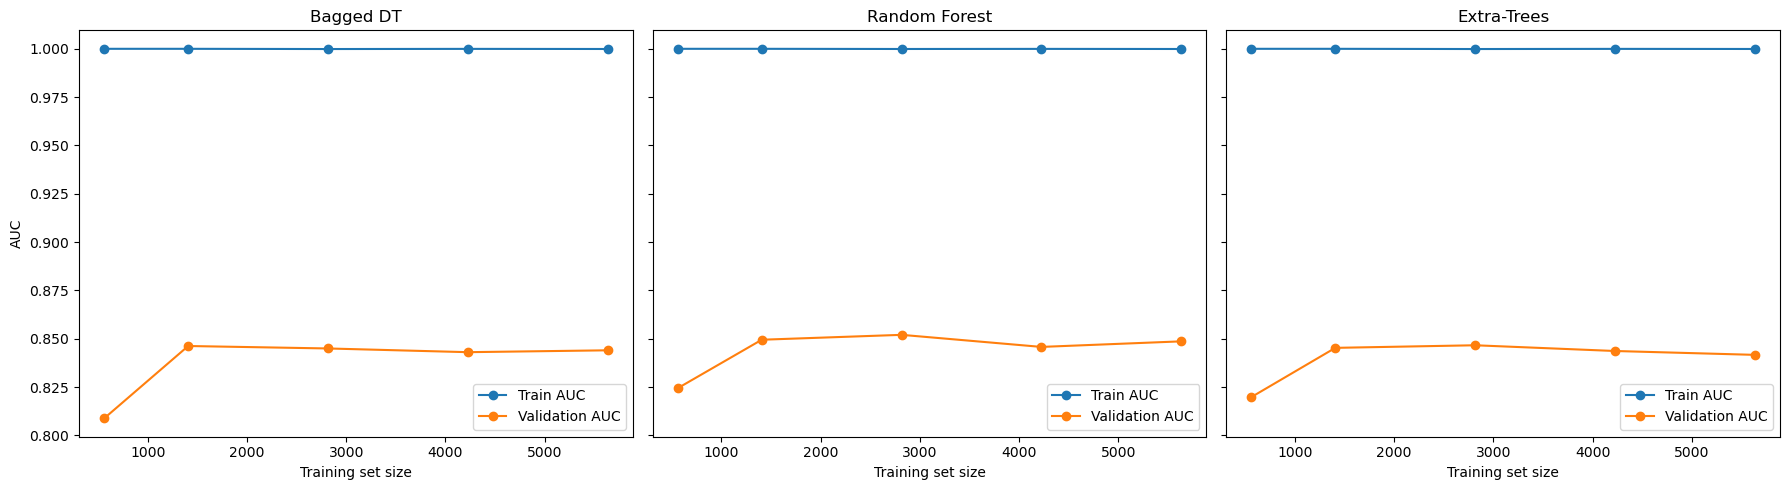


Train-validation AUC gap at 10% training size (bigger = more overfitting):
  Bagged DT: 0.1912
  Random Forest: 0.1756
  Extra-Trees: 0.1802


In [8]:
# ── Q4: RF vs Extra-Trees vs Bagged DT ───────────────────────────────────
# Compare three ensemble variants:
#   A: BaggingClassifier(base_estimator=DecisionTree, n_estimators=100)
#   B: RandomForestClassifier(n_estimators=100)
#   C: ExtraTreesClassifier(n_estimators=100)
#
# For each: 5-fold CV AUC, training time, OOB score
# Which is fastest? Which is most accurate?
# What does the bias-variance tradeoff look like across these three?
# Build a bias-variance visualization:
#   Train each on subsets of 10%, 25%, 50%, 75%, 100% of data
#   Plot train AUC + validation AUC vs training size
#   Which model shows most overfitting on small data?

import time
from sklearn.model_selection import train_test_split
from sklearn.base import clone

models_q4 = {
    'Bagged DT': BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=100,
        bootstrap=True, oob_score=True, random_state=420, n_jobs=-1,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, bootstrap=True, oob_score=True, random_state=420, n_jobs=-1,
    ),
    'Extra-Trees': ExtraTreesClassifier(
        n_estimators=100, bootstrap=True, oob_score=True, random_state=420, n_jobs=-1,
    ),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
results_q4 = {}

for name, model in models_q4.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc')

    results_q4[name] = {
        'Fit time (s)': fit_time,
        'OOB score': model.oob_score_,
        '5-fold CV AUC': cv_scores.mean(),
        'CV std': cv_scores.std(),
    }

comparison_q4 = pd.DataFrame(results_q4).T
print(comparison_q4.round(4))

# ── Bias-variance visualization: train vs validation AUC across data sizes ─
def get_subset(X, y, frac, random_state=420):
    if frac >= 1.0:
        return X, y
    X_sub, _, y_sub, _ = train_test_split(X, y, train_size=frac, stratify=y, random_state=random_state)
    return X_sub, y_sub

fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
curve_data = {name: {'train_auc': [], 'val_auc': []} for name in models_q4}

for name, model_template in models_q4.items():
    for frac in fractions:
        X_sub, y_sub = get_subset(X_train, y_train, frac)

        model = clone(model_template)
        model.fit(X_sub, y_sub)

        train_auc = roc_auc_score(y_sub, model.predict_proba(X_sub)[:, 1])
        val_auc = roc_auc_score(y_holdout, model.predict_proba(X_holdout)[:, 1])

        curve_data[name]['train_auc'].append(train_auc)
        curve_data[name]['val_auc'].append(val_auc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
train_sizes = [int(f * len(X_train)) for f in fractions]

for ax, name in zip(axes, models_q4):
    ax.plot(train_sizes, curve_data[name]['train_auc'], marker='o', label='Train AUC')
    ax.plot(train_sizes, curve_data[name]['val_auc'], marker='o', label='Validation AUC')
    ax.set_title(name)
    ax.set_xlabel('Training set size')
    ax.legend()

axes[0].set_ylabel('AUC')
plt.tight_layout()
plt.show()

# ── Overfitting gap at the smallest training size ──────────────────────────
print("\nTrain-validation AUC gap at 10% training size (bigger = more overfitting):")
for name in models_q4:
    gap = curve_data[name]['train_auc'][0] - curve_data[name]['val_auc'][0]
    print(f"  {name}: {gap:.4f}")


***Takeaway***

Random Forest wins across the board — fastest to fit (0.78s vs 1.71s for Bagged DT), most accurate (0.8141 CV AUC vs ~0.806 for the other two), and least overfitting on small data (0.1756 train-val gap). 

Bagged DT is the clear loser — slowest and not the most accurate and the worst overfitter, since it has no decorrelation mechanism (no feature subsampling, no threshold randomization) to keep its trees from being too similar to each other. 

Extra-Trees lands in the middle, statistically tied with Bagged DT on accuracy but with more fold-to-fold variance. 

One surprise: all three models hit a perfect 1.0 train AUC at every data size, meaning none of them are underfitting — so this experiment ended up measuring pure overfitting differences, not a real bias tradeoff, and an earlier guess that Extra-Trees would overfit least was wrong (RF did).